In [1]:
import coffea
import hist
import pickle
from coffea import util
import matplotlib.pyplot as plt
import itertools
import mplhep as hep
import uproot
from hist import plot
import numpy as np

In [2]:
fname = [
    'outputs/QCD_2016APV_800to1000_noSyst.coffea',
    'outputs/QCD_2016APV_1000to1400_noSyst.coffea',
    'outputs/QCD_2016APV_1400to1800_noSyst.coffea',
    'outputs/QCD_2016APV_1800to2400_noSyst.coffea',
    'outputs/QCD_2016APV_2400to3200_noSyst.coffea',
    'outputs/QCD_2016APV_3200toInf_noSyst.coffea'
]
gname = [
    'outputs/QCD_2016_800to1000_noSyst.coffea',
    'outputs/QCD_2016_1000to1400_noSyst.coffea',
    'outputs/QCD_2016_1400to1800_noSyst.coffea',
    'outputs/QCD_2016_1800to2400_noSyst.coffea',
    'outputs/QCD_2016_2400to3200_noSyst.coffea',
    'outputs/QCD_2016_3200toInf_noSyst.coffea'
]

f, g = [], []

In [3]:
for i in range(6):
    f.append(util.load(fname[i]))
    g.append(util.load(fname[i]))

In [4]:
# ttagcats = ["AT&Pt", "at", "pret", "0t", "1t", ">=1t", "2t", ">=0t"]
ttagcats = ['at', 'pret', '2t']
btagcats = ["0b", "1b", "2b"]
ycats = ['cen', 'fwd']                                                                                                          
anacats = [ t+b+y for t,b,y in itertools.product( ttagcats, btagcats, ycats) ]
label_dict = {i: label for i, label in enumerate(anacats)}

In [5]:
for i,j in enumerate(anacats):
    print(i, j)

0 at0bcen
1 at0bfwd
2 at1bcen
3 at1bfwd
4 at2bcen
5 at2bfwd
6 pret0bcen
7 pret0bfwd
8 pret1bcen
9 pret1bfwd
10 pret2bcen
11 pret2bfwd
12 2t0bcen
13 2t0bfwd
14 2t1bcen
15 2t1bfwd
16 2t2bcen
17 2t2bfwd


In [6]:
f[2]['ttbarmass_bare'].project("anacat", "ttbarmass")

Hist(
  IntCategory([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], name='anacat', label='Analysis Category'),
  Regular(50, 800, 8000, name='ttbarmass', label='$m_{t\\bar{t}}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=1.10159e+06, variance=1.10159e+06) (WeightedSum(value=1.10172e+06, variance=1.10172e+06) with flow)

/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not plac

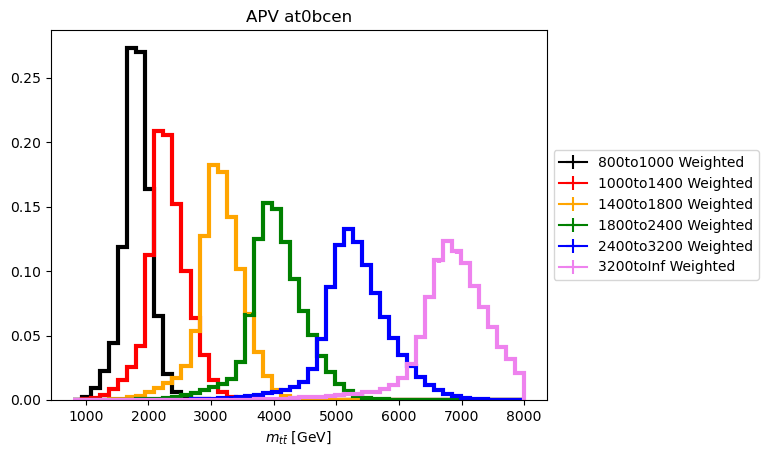

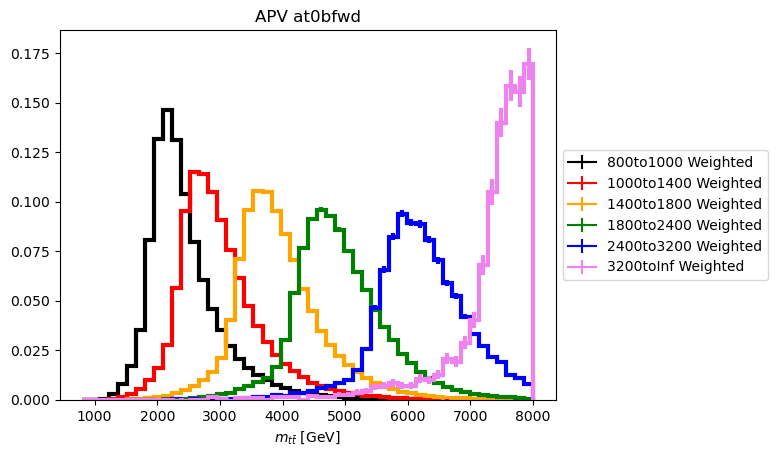

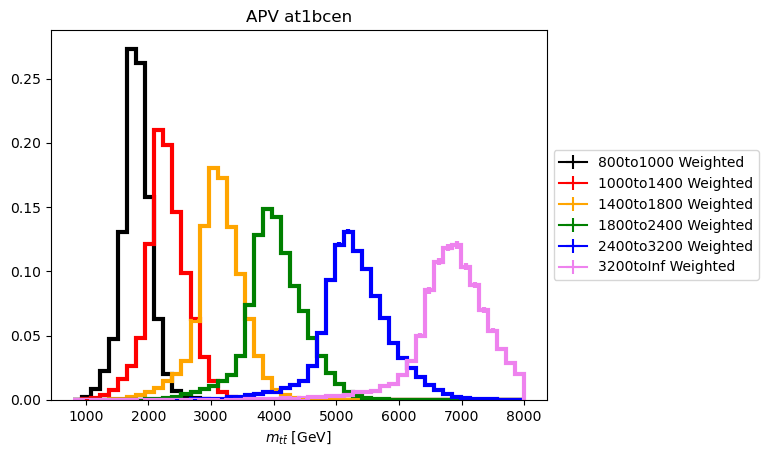

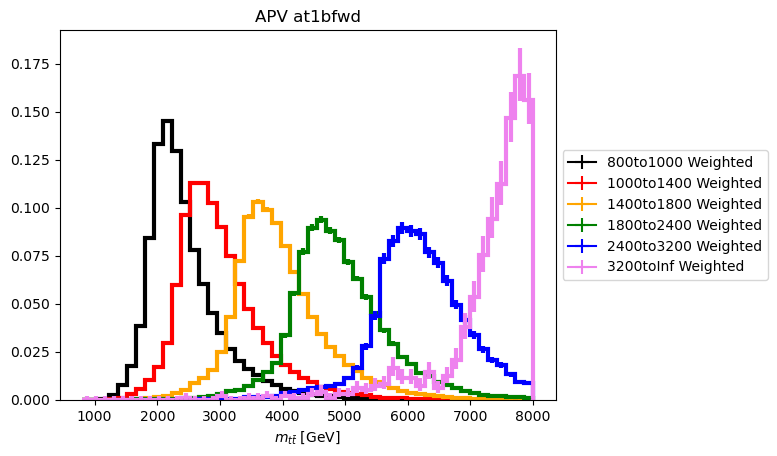

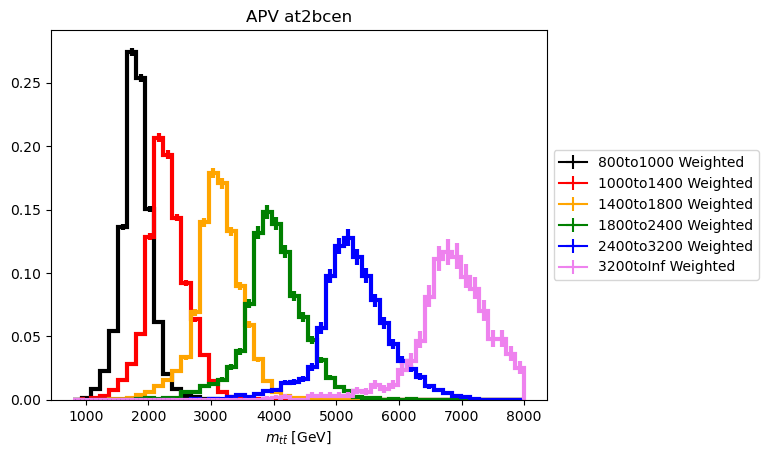

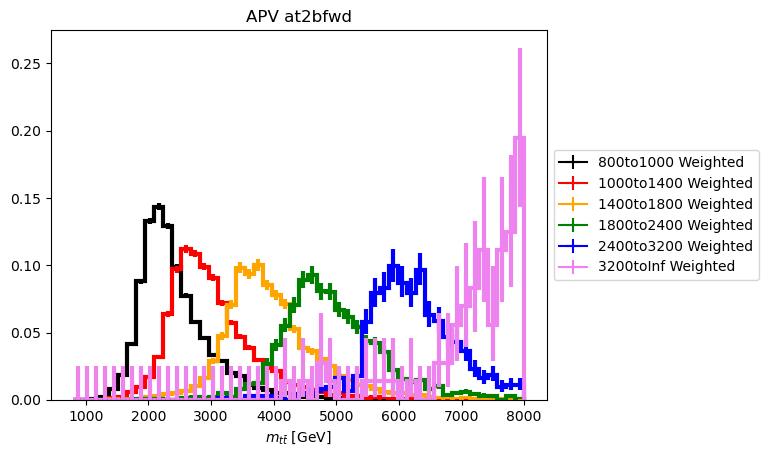

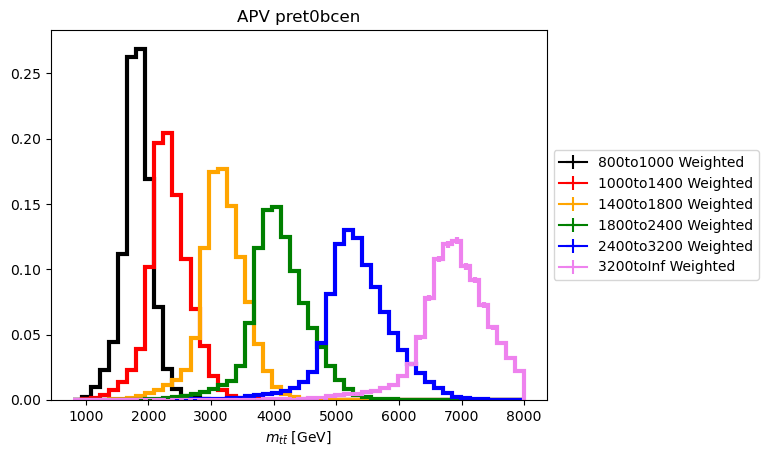

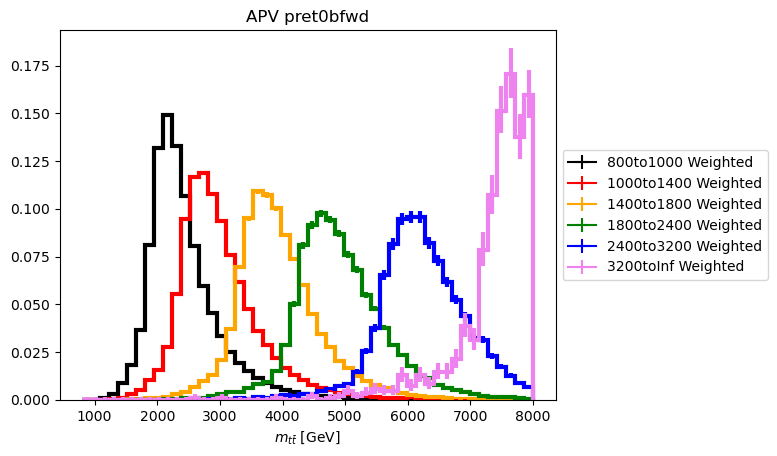

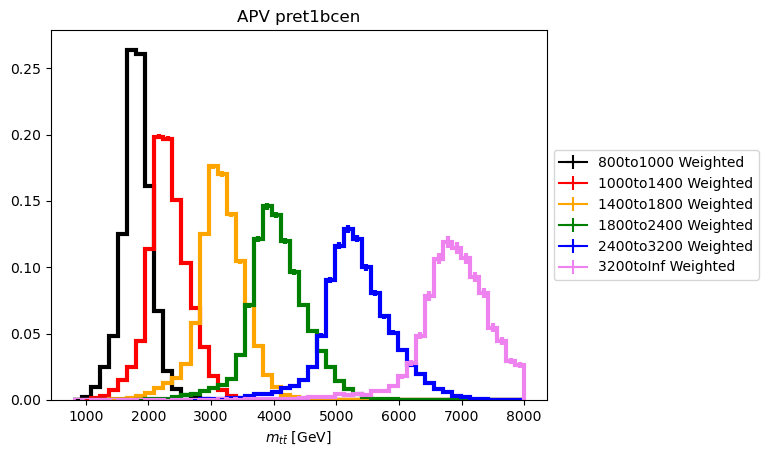

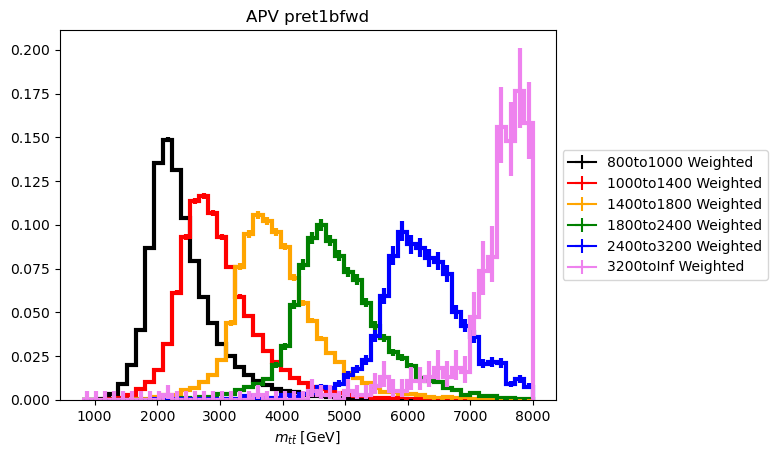

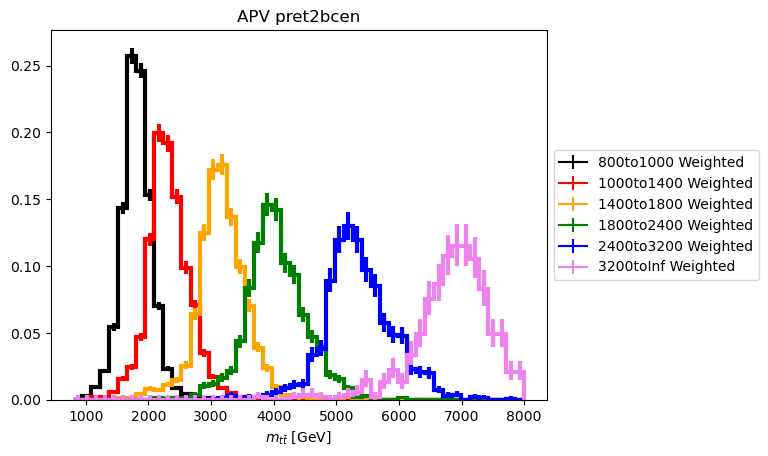

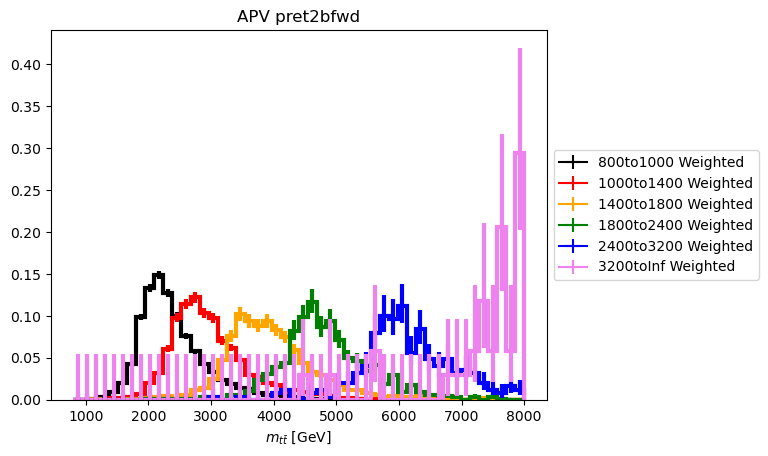

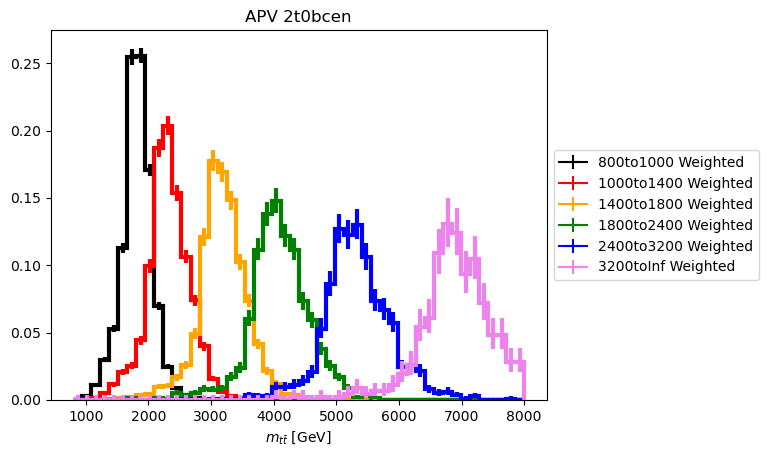

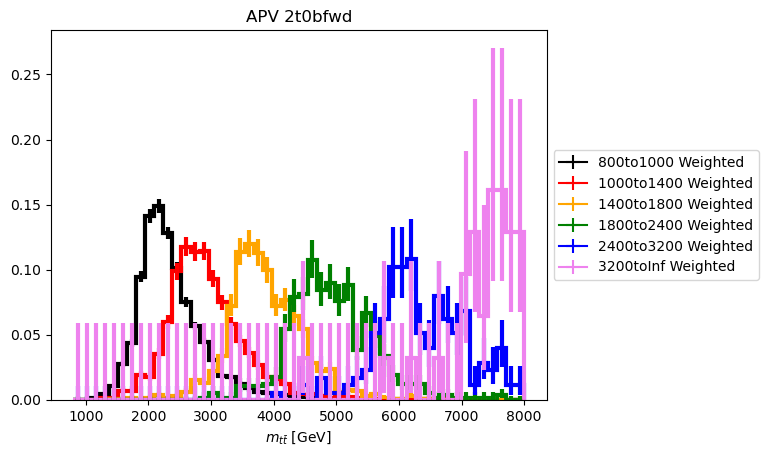

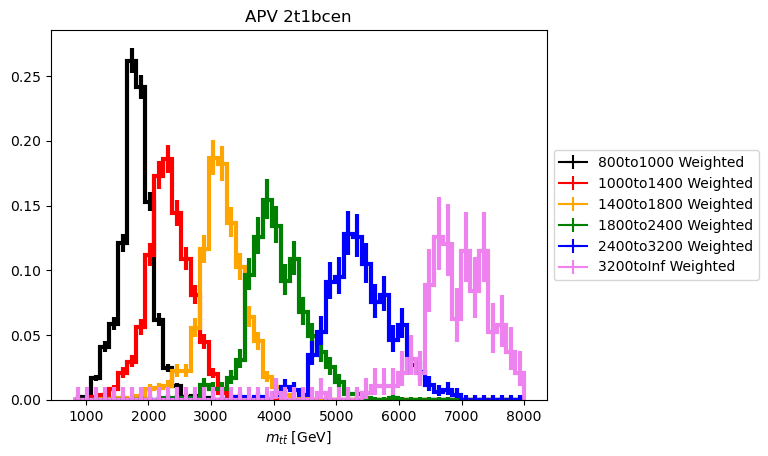

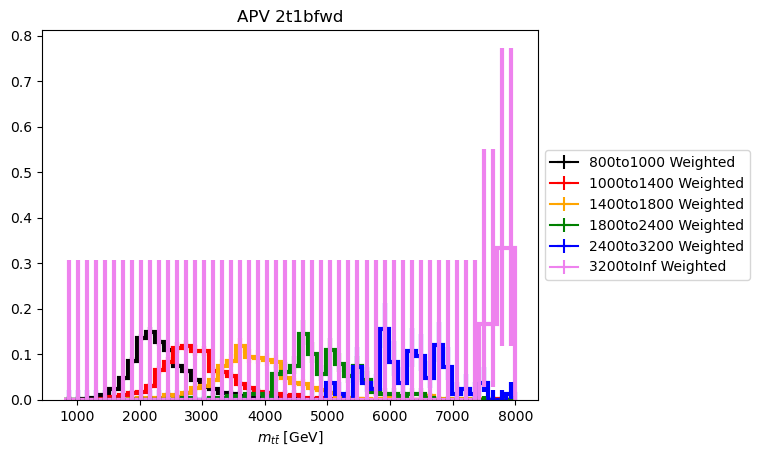

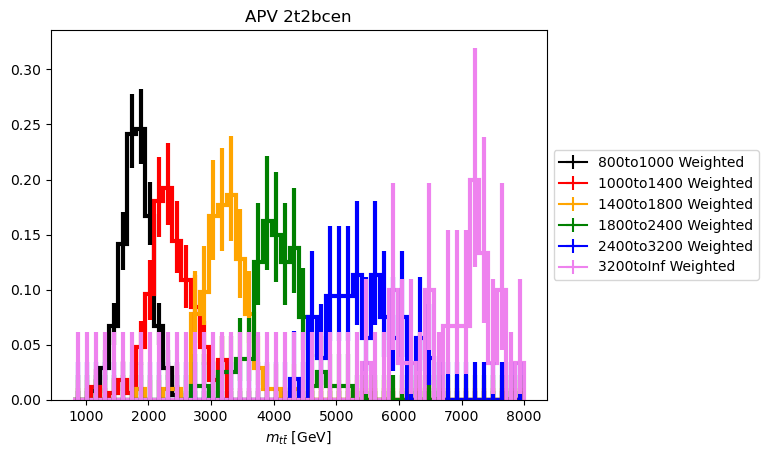

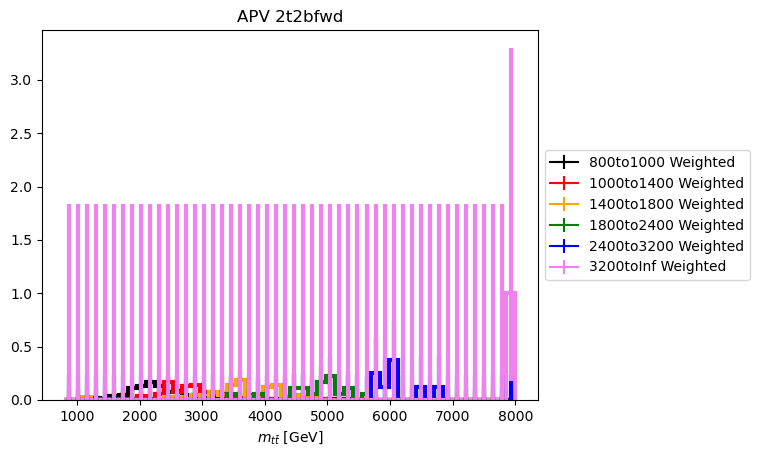

In [8]:
Color = ['black', 'red', 'orange', 'green', 'blue', 'violet']
ptRange = ['800to1000', '1000to1400', '1400to1800', '1800to2400', '2400to3200', '3200toInf']
for icat in range(18):
    fig = plt.figure(icat+1)
    for i in range(0,6):
        
        # f[i]['ttbarmass_bare'].project("anacat", "ttbarmass")[icat,:].plot(label=ptRange[i]+" Bare", color=Color[i], density=True)
        # f[i]['ttbarmass_fine'].project("anacat", "ttbarmass")[icat,:].plot(label=ptRange[i]+" Weighted", color=Color[i], ls=':', lw=3, density=True)
        
        # fbare = f[i]['ttbarmass_bare'][{'anacat':[icat], 'systematic':'nominal'}][{'anacat':sum}] / f[i]['cutflow']['sumw']
        ffine = f[i]['ttbarmass_fine'][{'anacat':[icat], 'systematic':'nominal'}][{'anacat':sum}] * 19800. * 1370000000./ f[i]['cutflow']['sumw']
        ffine = ffine / np.sum(ffine.values())
        
        # hep.histplot(fbare/np.sum(fbare.values()), color=Color[i], ls=':', lw=3, label=ptRange[i]+" Bare")
        hep.histplot(ffine, color=Color[i], lw=3, label=ptRange[i]+" Weighted")
        
    plt.title("APV " + anacats[icat])
    
    plt.legend(loc='center left', bbox_to_anchor=(1,0.5))
    # plt.savefig("apv_"+anacats[icat] +".png")

In [ ]:
Color = ['black', 'red', 'orange', 'green', 'blue', 'violet']
ptRange = ['800to1000', '1000to1400', '1400to1800', '1800to2400', '2400to3200', '3200toInf']
for icat in range(18):
    fig = plt.figure(icat+1)
    for i in range(0,6):
        
        # g[i]['ttbarmass_bare'].project("anacat", "ttbarmass")[icat,:].plot(label=ptRange[i]+" Bare", color=Color[i], density=True)
        # g[i]['ttbarmass_fine'].project("anacat", "ttbarmass")[icat,:].plot(label=ptRange[i]+" Weighted", color=Color[i], ls=':', lw=3, density=True)
        
        # gbare = g[i]['ttbarmass_bare'][{'anacat':[icat], 'systematic':'nominal'}][{'anacat':sum}] / g[i]['cutflow']['sumw']
        gfine = g[i]['ttbarmass_fine'][{'anacat':[icat], 'systematic':'nominal'}][{'anacat':sum}] * 16120. / g[i]['cutflow']['sumw']
        
        
        # hep.histplot(gbare/np.sum(gbare.values()), color=Color[i], ls=':', lw=3, label=ptRange[i]+" Bare")
        hep.histplot(gfine/np.sum(gfine.values()), color=Color[i], lw=3, label=ptRange[i]+" Weighted")
        
    plt.title("no APV " + anacats[icat])
    
    plt.legend(loc='center left', bbox_to_anchor=(1,0.5))
    # plt.savefig("noapv_"+anacats[icat] +".png")

In [ ]:
g[0]['ttbarmass_fine'].project("anacat", "ttbarmass")[6,:].plot()
plt.yscale("log")

In [ ]:
g[0]['ttbarmass_fine'].project("anacat", "ttbarmass")[6,:].plot()

In [ ]:
g[0]['ttbarmass_fine'].project("anacat", "ttbarmass")[6,:].axes.edges

In [ ]:
g[0]['ttbarmass_fine'].project("anacat", "ttbarmass")[6,:].values()

In [ ]:
f[0]['ttbarmass_fine'].project("anacat", "ttbarmass")[6,:].values()

In [ ]:
f[0]['ttbarmass_bare'].project("anacat", "ttbarmass")[6,:].plot()

In [ ]:
g[0]['ttbarmass_bare'].project("anacat", "ttbarmass")[6,:].plot()